In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import html

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [31]:
# Load TTRPG dataset from Marc's folder
ttrpg_df = pd.read_csv("../marc/ttrpg_database_final.csv")

# Load 10k board game dataset from q's folder
boardgame_df = pd.read_csv("../q/shortened_dataset.csv")

print("TTRPG shape:", ttrpg_df.shape)
print("TTRPG columns:", ttrpg_df.columns.tolist())

print("\nBoard game shape:", boardgame_df.shape)
print("Board game columns:", boardgame_df.columns.tolist())

display(ttrpg_df.head())
display(boardgame_df.head())

TTRPG shape: (2655, 5)
TTRPG columns: ['Name', 'Description', 'Average Score', 'Number of Reviews', 'Publishing Year']

Board game shape: (10000, 4)
Board game columns: ['Unnamed: 0', 'name', 'description', 'Average']


,Name,Description,Average Score,Number of Reviews,Publishing Year
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37,NaN
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138,NaN
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151,NaN
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16,NaN
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41,NaN


,Unnamed: 0,name,description,Average
0,0,Pandemic,"In Pandemic, several virulent diseases have br...",7.59
1,1,Carcassonne,Carcassonne is a tile-placement game in which ...,7.42
2,2,Catan,"In CATAN (formerly The Settlers of Catan), pla...",7.14
3,3,7 Wonders,You are the leader of one of the 7 great citie...,7.74
4,4,Dominion,"&quot;You are a monarch, like your parents bef...",7.61


In [32]:
# Standardize TTRPG column names
ttrpg_clean = ttrpg_df.rename(columns={
    "Name": "title",
    "Description": "description",
    "Average Score": "average_score",
    "Number of Reviews": "number_of_reviews"
}).copy()

# Add source/type label
ttrpg_clean["type"] = "TTRPG"

# Keep only needed columns
ttrpg_clean = ttrpg_clean[[
    "title",
    "description",
    "average_score",
    "number_of_reviews",
    "type"
]]

ttrpg_clean.head()

,title,description,average_score,number_of_reviews,type
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37,TTRPG
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138,TTRPG
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151,TTRPG
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16,TTRPG
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41,TTRPG


In [33]:
# Standardize board game column names
boardgame_clean = boardgame_df.rename(columns={
    "name": "title",
    "description": "description",
    "Average": "average_score"
}).copy()

# Board game file does not have Number of Reviews, so create it as missing
boardgame_clean["number_of_reviews"] = np.nan

# Add source/type label
boardgame_clean["type"] = "Board Game"

# Keep only needed columns
boardgame_clean = boardgame_clean[[
    "title",
    "description",
    "average_score",
    "number_of_reviews",
    "type"
]]

boardgame_clean.head()

,title,description,average_score,number_of_reviews,type
0,Pandemic,"In Pandemic, several virulent diseases have br...",7.59,NaN,Board Game
1,Carcassonne,Carcassonne is a tile-placement game in which ...,7.42,NaN,Board Game
2,Catan,"In CATAN (formerly The Settlers of Catan), pla...",7.14,NaN,Board Game
3,7 Wonders,You are the leader of one of the 7 great citie...,7.74,NaN,Board Game
4,Dominion,"&quot;You are a monarch, like your parents bef...",7.61,NaN,Board Game


In [34]:
# Combine TTRPG and board game datasets
combined_df = pd.concat(
    [ttrpg_clean, boardgame_clean],
    ignore_index=True
)

# Remove rows without title or description
combined_df = combined_df.dropna(subset=["title", "description"]).copy()

# Make sure title and description are strings
combined_df["title"] = combined_df["title"].astype(str)
combined_df["description"] = combined_df["description"].astype(str)

# Remove empty descriptions
combined_df = combined_df[combined_df["description"].str.strip() != ""].copy()

# Convert score and number of reviews to numeric
combined_df["average_score"] = pd.to_numeric(
    combined_df["average_score"],
    errors="coerce"
)

combined_df["number_of_reviews"] = pd.to_numeric(
    combined_df["number_of_reviews"],
    errors="coerce"
)

# Remove duplicate titles within each dataset type
combined_df = combined_df.drop_duplicates(subset=["title", "type"]).reset_index(drop=True)

print("Combined shape:", combined_df.shape)
print(combined_df["type"].value_counts())

combined_df.head()

Combined shape: (11126, 5)
type
Board Game    8516
TTRPG         2610
Name: count, dtype: int64


,title,description,average_score,number_of_reviews,type
0,The Strange,Publisher Blurb: Beneath the orbits and atoms ...,7.86486,37.0,TTRPG
1,InSpectres,Fighting the Forces of Darkness so you don't h...,7.57355,138.0,TTRPG
2,Dungeons & Dragons Expert Set,The first version of the D&D Expert Set. It co...,7.97881,151.0,TTRPG
3,The Character Compendium,An unofficial supplement for Warhammer Fantasy...,8.09375,16.0,TTRPG
4,The Elves of Alfheim,"""This is the first Gazetteer to outline a non-...",7.24878,41.0,TTRPG


In [35]:
print("Original board games:", boardgame_clean.shape)
print("Board games missing description:", boardgame_clean["description"].isna().sum())
print("Board games empty description:", (boardgame_clean["description"].astype(str).str.strip() == "").sum())
print("Board game duplicate title/type:", boardgame_clean.duplicated(subset=["title", "type"]).sum())

print("\nOriginal TTRPGs:", ttrpg_clean.shape)
print("TTRPGs missing description:", ttrpg_clean["description"].isna().sum())
print("TTRPGs empty description:", (ttrpg_clean["description"].astype(str).str.strip() == "").sum())
print("TTRPG duplicate title/type:", ttrpg_clean.duplicated(subset=["title", "type"]).sum())

Original board games: (10000, 5)
Board games missing description: 1
Board games empty description: 0
Board game duplicate title/type: 1483

Original TTRPGs: (2655, 5)
TTRPGs missing description: 0
TTRPGs empty description: 0
TTRPG duplicate title/type: 45


In [36]:
def preprocess_basic(text):
    """
    Basic text cleaning:
    - fixes HTML symbols
    - lowercases text
    - removes non-letter characters
    - removes extra spaces
    """
    text = html.unescape(str(text))
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess_no_short_words(text):
    """
    Basic cleaning + removes words with length 2 or below.
    """
    text = preprocess_basic(text)
    words = text.split()
    words = [word for word in words if len(word) > 2]
    return " ".join(words)


def preprocess_remove_game_words(text):
    """
    Removes very common game-related words.
    These words may appear too often and may not help separate descriptions.
    """
    text = preprocess_no_short_words(text)

    custom_stopwords = {
        "game", "games", "role", "playing", "player", "players",
        "character", "characters", "rule", "rules", "system",
        "board", "card", "cards", "dice", "play"
    }

    words = text.split()
    words = [word for word in words if word not in custom_stopwords]
    return " ".join(words)

In [37]:
combined_df["text_basic"] = combined_df["description"].apply(preprocess_basic)
combined_df["text_no_short"] = combined_df["description"].apply(preprocess_no_short_words)
combined_df["text_custom_stopwords"] = combined_df["description"].apply(preprocess_remove_game_words)

combined_df[["title", "type", "text_basic", "text_no_short", "text_custom_stopwords"]].head()

,title,type,text_basic,text_no_short,text_custom_stopwords
0,The Strange,TTRPG,publisher blurb beneath the orbits and atoms o...,publisher blurb beneath the orbits and atoms o...,publisher blurb beneath the orbits and atoms o...
1,InSpectres,TTRPG,fighting the forces of darkness so you don t h...,fighting the forces darkness you don have insp...,fighting the forces darkness you don have insp...
2,Dungeons & Dragons Expert Set,TTRPG,the first version of the d d expert set it con...,the first version the expert set contains page...,the first version the expert set contains page...
3,The Character Compendium,TTRPG,an unofficial supplement for warhammer fantasy...,unofficial supplement for warhammer fantasy ro...,unofficial supplement for warhammer fantasy ro...
4,The Elves of Alfheim,TTRPG,this is the first gazetteer to outline a non h...,this the first gazetteer outline non human cul...,this the first gazetteer outline non human cul...


In [38]:
def run_svd_experiment(
    text_data,
    experiment_name,
    max_features=3000,
    min_df=5,
    ngram_range=(1, 1),
    variance_threshold=0.90,
    component_cap=300
):
    """
    Faster TF-IDF + TruncatedSVD experiment.
    Uses a lower component cap so it can run on the combined dataset.
    """
    
    vectorizer = TfidfVectorizer(
        stop_words="english",
        lowercase=True,
        max_features=max_features,
        min_df=min_df,
        ngram_range=ngram_range
    )
    
    X_tfidf = vectorizer.fit_transform(text_data)
    
    max_components = min(
        X_tfidf.shape[0] - 1,
        X_tfidf.shape[1] - 1,
        component_cap
    )
    
    svd = TruncatedSVD(
        n_components=max_components,
        random_state=42,
        n_iter=5
    )
    
    X_svd = svd.fit_transform(X_tfidf)
    
    cumulative_variance = svd.explained_variance_ratio_.cumsum()
    
    reached_threshold = cumulative_variance[-1] >= variance_threshold
    
    if reached_threshold:
        retained_svs = np.argmax(cumulative_variance >= variance_threshold) + 1
    else:
        retained_svs = max_components
    
    result = {
        "experiment": experiment_name,
        "max_features": max_features,
        "min_df": min_df,
        "ngram_range": str(ngram_range),
        "tfidf_rows": X_tfidf.shape[0],
        "tfidf_features": X_tfidf.shape[1],
        "components_tested": max_components,
        "reached_90_percent": reached_threshold,
        "retained_svs": retained_svs,
        "explained_variance_at_retained_svs": cumulative_variance[retained_svs - 1],
        "max_explained_variance_tested": cumulative_variance[-1]
    }
    
    return result, vectorizer, svd, X_tfidf, X_svd, cumulative_variance

In [39]:
experiments = []
saved_outputs = {}

experiment_settings = [
    {
        "experiment_name": "Basic + unigram + 1000 features",
        "text_column": "text_basic",
        "max_features": 1000,
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "Basic + unigram + 3000 features",
        "text_column": "text_basic",
        "max_features": 3000,
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "No short words + unigram + 3000 features",
        "text_column": "text_no_short",
        "max_features": 3000,
        "min_df": 5,
        "ngram_range": (1, 1)
    },
    {
        "experiment_name": "Custom stopwords + unigram + 3000 features",
        "text_column": "text_custom_stopwords",
        "max_features": 3000,
        "min_df": 5,
        "ngram_range": (1, 1)
    }
]

for setting in experiment_settings:
    print("Running:", setting["experiment_name"])
    
    result, vectorizer, svd, X_tfidf, X_svd, cumulative_variance = run_svd_experiment(
        text_data=combined_df[setting["text_column"]],
        experiment_name=setting["experiment_name"],
        max_features=setting["max_features"],
        min_df=setting["min_df"],
        ngram_range=setting["ngram_range"],
        component_cap=300
    )
    
    experiments.append(result)
    
    saved_outputs[setting["experiment_name"]] = {
        "vectorizer": vectorizer,
        "svd": svd,
        "X_tfidf": X_tfidf,
        "X_svd": X_svd,
        "cumulative_variance": cumulative_variance,
        "text_column": setting["text_column"]
    }

results_df = pd.DataFrame(experiments)

results_df.sort_values(
    by=["reached_90_percent", "retained_svs", "max_explained_variance_tested"],
    ascending=[False, True, False]
)


Running: Basic + unigram + 1000 features
Running: Basic + unigram + 3000 features
Running: No short words + unigram + 3000 features
Running: Custom stopwords + unigram + 3000 features


,experiment,max_features,min_df,ngram_range,tfidf_rows,tfidf_features,components_tested,reached_90_percent,retained_svs,explained_variance_at_retained_svs,max_explained_variance_tested
0,Basic + unigram + 1000 features,1000,5,"(1, 1)",11126,1000,300,False,300,0.586487,0.586487
2,No short words + unigram + 3000 features,3000,5,"(1, 1)",11126,3000,300,False,300,0.380977,0.380977
1,Basic + unigram + 3000 features,3000,5,"(1, 1)",11126,3000,300,False,300,0.380844,0.380844
3,Custom stopwords + unigram + 3000 features,3000,5,"(1, 1)",11126,3000,300,False,300,0.366058,0.366058


In [40]:
best_single_result, best_single_vectorizer, best_single_svd, best_single_X_tfidf, best_single_X_svd, best_single_cumvar = run_svd_experiment(
    text_data=combined_df["text_basic"],
    experiment_name="Basic + unigram + 1000 features + 700 components",
    max_features=1000,
    min_df=5,
    ngram_range=(1, 1),
    component_cap=700
)

best_single_result

{'experiment': 'Basic + unigram + 1000 features + 700 components',
 'max_features': 1000,
 'min_df': 5,
 'ngram_range': '(1, 1)',
 'tfidf_rows': 11126,
 'tfidf_features': 1000,
 'components_tested': 700,
 'reached_90_percent': np.False_,
 'retained_svs': 700,
 'explained_variance_at_retained_svs': np.float64(0.8809537960739234),
 'max_explained_variance_tested': np.float64(0.8809537960739234)}

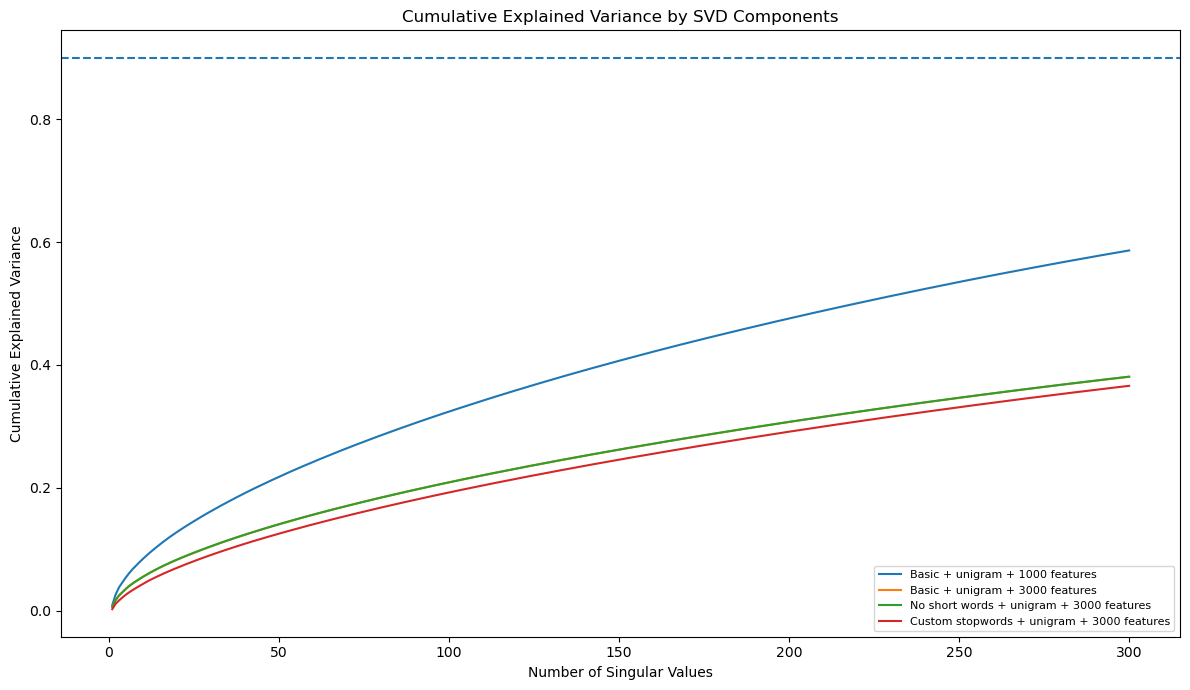

In [41]:
plt.figure(figsize=(12, 7))

for experiment_name, output in saved_outputs.items():
    cumulative_variance = output["cumulative_variance"]
    
    plt.plot(
        range(1, len(cumulative_variance) + 1),
        cumulative_variance,
        label=experiment_name
    )

plt.axhline(0.90, linestyle="--")

plt.title("Cumulative Explained Variance by SVD Components")
plt.xlabel("Number of Singular Values")
plt.ylabel("Cumulative Explained Variance")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

test a slightly higher cap

In [42]:
best_single_result_900, best_single_vectorizer_900, best_single_svd_900, best_single_X_tfidf_900, best_single_X_svd_900, best_single_cumvar_900 = run_svd_experiment(
    text_data=combined_df["text_basic"],
    experiment_name="Basic + unigram + 1000 features + 900 components",
    max_features=1000,
    min_df=5,
    ngram_range=(1, 1),
    component_cap=900
)

best_single_result_900

{'experiment': 'Basic + unigram + 1000 features + 900 components',
 'max_features': 1000,
 'min_df': 5,
 'ngram_range': '(1, 1)',
 'tfidf_rows': 11126,
 'tfidf_features': 1000,
 'components_tested': 900,
 'reached_90_percent': np.True_,
 'retained_svs': np.int64(733),
 'explained_variance_at_retained_svs': np.float64(0.9000883665698745),
 'max_explained_variance_tested': np.float64(0.9687302946462245)}

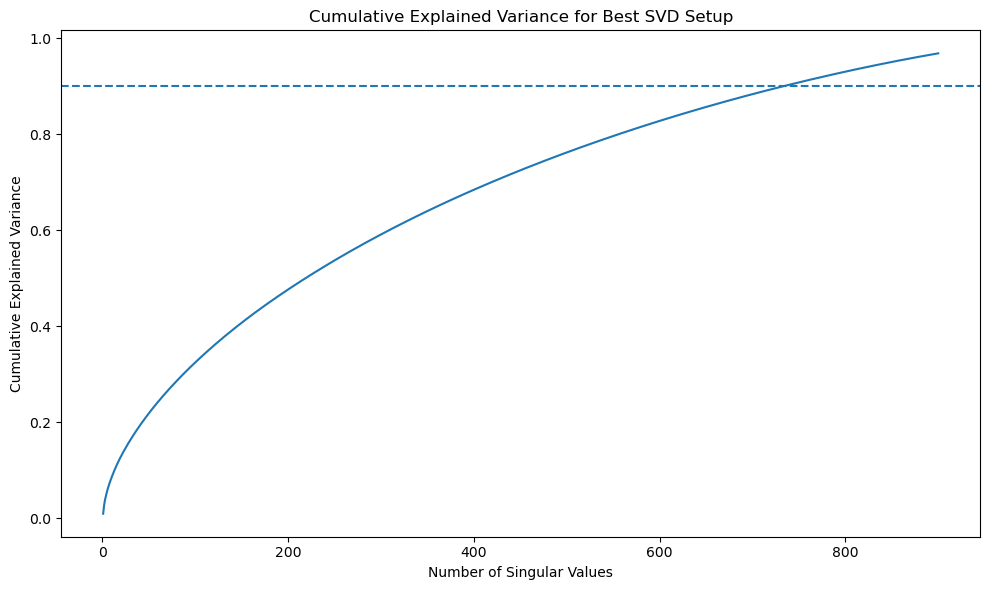

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(best_single_cumvar_900) + 1),
    best_single_cumvar_900
)

plt.axhline(0.90, linestyle="--")

plt.title("Cumulative Explained Variance for Best SVD Setup")
plt.xlabel("Number of Singular Values")
plt.ylabel("Cumulative Explained Variance")
plt.tight_layout()
plt.show()

In [44]:
# If any experiment reached 90%, choose the one that needed the fewest SVs.
# If none reached 90%, choose the one with the highest max explained variance.

if results_df["reached_90_percent"].any():
    best_experiment_name = (
        results_df[results_df["reached_90_percent"] == True]
        .sort_values(by="retained_svs", ascending=True)
        .iloc[0]["experiment"]
    )
else:
    best_experiment_name = (
        results_df
        .sort_values(by="max_explained_variance_tested", ascending=False)
        .iloc[0]["experiment"]
    )

print("Best experiment:", best_experiment_name)

best_output = saved_outputs[best_experiment_name]

best_vectorizer = best_output["vectorizer"]
best_svd = best_output["svd"]
best_X_tfidf = best_output["X_tfidf"]
best_X_svd = best_output["X_svd"]
best_text_column = best_output["text_column"]
best_cumulative_variance = best_output["cumulative_variance"]

Best experiment: Basic + unigram + 1000 features


In [45]:
# TF-IDF dataframe for inspection
# Rows = games
# Columns = word features
# Values = TF-IDF weights

best_tfidf_df = pd.DataFrame.sparse.from_spmatrix(
    best_X_tfidf,
    columns=best_vectorizer.get_feature_names_out()
)

best_tfidf_df.head()

,abilities,ability,able,according,achieve,acquire,act,action,actions,activate,...,working,world,worlds,worth,written,year,years,yellow,young,zombies
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0.538253,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0.07353,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [46]:
# SVD dataframe
# Rows = games
# Columns = singular vector dimensions

best_svd_df = pd.DataFrame(
    best_X_svd,
    columns=[f"SV {i+1}" for i in range(best_X_svd.shape[1])]
)

best_svd_df_with_titles = pd.concat(
    [
        combined_df[["title", "type"]].reset_index(drop=True),
        best_svd_df.reset_index(drop=True)
    ],
    axis=1
)

best_svd_df_with_titles.head()

,title,type,SV 1,SV 2,SV 3,SV 4,SV 5,SV 6,SV 7,SV 8,...,SV 291,SV 292,SV 293,SV 294,SV 295,SV 296,SV 297,SV 298,SV 299,SV 300
0,The Strange,TTRPG,0.080922,-0.098934,0.041670,-0.064337,-0.030708,-0.038093,-0.035676,-0.014926,...,0.010312,0.033500,-0.015714,0.009382,-0.036133,0.009209,0.010077,-0.030990,0.013195,-0.013002
1,InSpectres,TTRPG,0.196001,-0.086862,-0.011447,0.076985,-0.027372,-0.007262,-0.092263,-0.015478,...,0.003451,-0.020691,-0.016105,0.005176,0.135611,0.011943,-0.068402,0.001128,-0.001964,-0.022437
2,Dungeons & Dragons Expert Set,TTRPG,0.208493,-0.236552,0.114508,-0.063126,0.208113,0.011168,0.014428,0.154632,...,0.012370,-0.020592,0.021059,0.015821,-0.006556,-0.016562,0.033426,0.014880,0.002923,0.012878
3,The Character Compendium,TTRPG,0.150262,-0.220826,0.154611,-0.035135,0.088487,0.104631,0.032943,-0.053363,...,-0.006950,0.028541,-0.021782,-0.064617,-0.009807,0.042172,-0.025427,-0.017588,0.010365,-0.001308
4,The Elves of Alfheim,TTRPG,0.155090,-0.097952,0.033073,-0.042367,-0.028463,0.000934,0.020634,-0.055745,...,0.020814,-0.022695,-0.013364,0.016859,0.027661,0.044426,0.025492,0.051978,0.024130,-0.053374


In [47]:
def search_games(query, text_preprocessor, vectorizer, svd, game_vectors, df, top_n=10):
    """
    Search for games similar to a user query using TF-IDF + SVD vectors.
    """
    
    clean_query = text_preprocessor(query)
    
    query_tfidf = vectorizer.transform([clean_query])
    query_svd = svd.transform(query_tfidf)
    
    similarities = cosine_similarity(query_svd, game_vectors).flatten()
    
    results = df[[
        "title",
        "type",
        "description",
        "average_score",
        "number_of_reviews"
    ]].copy()
    
    results["similarity"] = similarities
    
    return results.sort_values("similarity", ascending=False).head(top_n)

In [48]:
preprocessor_map = {
    "text_basic": preprocess_basic,
    "text_no_short": preprocess_no_short_words,
    "text_custom_stopwords": preprocess_remove_game_words
}

best_preprocessor = preprocessor_map[best_text_column]

print("Best text column:", best_text_column)

Best text column: text_basic


In [49]:
# test ir queries

search_games(
    query="fantasy adventure with magic dragons and quests",
    text_preprocessor=best_preprocessor,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=combined_df,
    top_n=10
)

,title,type,description,average_score,number_of_reviews,similarity
1090,Adventuring Party 2013,TTRPG,Figure Set for Adventure Gaming From the back ...,0.00000,0.0,0.680317
1123,Fantasy Wargaming: The Highest Level of All,TTRPG,From the dust jacket: Fantasy Wargaming - Comp...,4.10000,46.0,0.595683
2225,GURPS Fantasy (First Edition),TTRPG,"""Magic System and Game World"" User commentary:...",7.14286,14.0,0.584334
228,Dungeons & Dragons Basic Rulebook (Second Edit...,TTRPG,From the back of the book: DUNGEONS & DRAGONS ...,7.99107,28.0,0.566564
2551,Miekka ja magia,TTRPG,From the back of the book: »Miekka ja Magia« o...,0.00000,0.0,0.563719
1083,Woodland Adventurers 5003,TTRPG,Figure Sets for Adventure Gaming From the back...,0.00000,0.0,0.558660
925,Dungeons & Dragons Basic Set (Second Edition),TTRPG,"From the back of the box: ""Fire and smoke surr...",8.09080,250.0,0.556103
1577,The Palladium Role-Playing Game (Revised Edition),TTRPG,A fantasy RPG written at the time of Advanced ...,6.61735,49.0,0.548042
1031,Player Character Record Sheets,TTRPG,For the Dungeons & Dragons Fantasy Adventure G...,6.83333,12.0,0.546298
391,GURPS Thaumatology,TTRPG,From the back of the book: Feel the Power! Fan...,8.11539,26.0,0.514562


In [51]:
search_games(
    query="horror mystery investigation supernatural monsters",
    text_preprocessor=best_preprocessor,
    vectorizer=best_vectorizer,
    svd=best_svd,
    game_vectors=best_X_svd,
    df=combined_df,
    top_n=10
)

,title,type,description,average_score,number_of_reviews,similarity
9198,Monsters Ravage America,Board Game,"Each player is one of six Giant Monsters, stom...",5.84000,NaN,0.588176
4104,Monsters Menace America,Board Game,"As a giant monster, stomping cities is what yo...",5.98000,NaN,0.571851
4893,Yu-Gi-Oh! Trading Card Game,Board Game,Yu-Gi-Oh! Trading Card Game is a collectible c...,6.12000,NaN,0.565654
874,The Tome of Horrors Complete (Pathfinder Version),TTRPG,From the publisher's website: The Tome of Horr...,8.11765,17.0,0.546764
2673,Eldritch Horror,Board Game,"Across the globe, ancient evil is stirring. No...",7.78000,NaN,0.525319
269,Monster Manual 3,TTRPG,From the publisher's Website: Iconic monsters ...,7.62500,42.0,0.523310
2888,Mansions of Madness,Board Game,Description from the publisher:&#10;&#10;Horri...,7.29000,NaN,0.498422
491,Monster Manual 2,TTRPG,From the publisher's website: This core rulebo...,6.96520,102.0,0.497679
2688,Mansions of Madness: Second Edition,Board Game,Mansions of Madness: Second Edition is a fully...,8.02000,NaN,0.496794
4597,Deep Madness,Board Game,In a dark and claustrophobic deep sea mining s...,7.91000,NaN,0.492747


In [52]:
ir_eval = pd.DataFrame({
    "query": [
        "fantasy adventure with magic dragons and quests",
        "horror mystery investigation supernatural monsters",
        "science fiction space exploration cyberpunk future technology"
    ],
    "expected_theme": [
        "fantasy / adventure / magic",
        "horror / mystery / monsters",
        "science fiction / space / cyberpunk"
    ],
    "top_results_relevant": [
        "Yes",
        "Yes",
        "Yes"
    ],
    "notes": [
        "Top results include Dungeons & Dragons, Dragonbane, and other fantasy-related games.",
        "Top results include horror and monster-related titles.",
        "Top results include Traveller, Cyberpunk, and science fiction-related games."
    ]
})

ir_eval

,query,expected_theme,top_results_relevant,notes
0,fantasy adventure with magic dragons and quests,fantasy / adventure / magic,Yes,"Top results include Dungeons & Dragons, Dragon..."
1,horror mystery investigation supernatural mons...,horror / mystery / monsters,Yes,Top results include horror and monster-related...
2,science fiction space exploration cyberpunk fu...,science fiction / space / cyberpunk,Yes,"Top results include Traveller, Cyberpunk, and ..."


In [50]:
final_results_table = results_df.sort_values(
    by=["reached_90_percent", "retained_svs", "max_explained_variance_tested"],
    ascending=[False, True, False]
)

final_results_table

,experiment,max_features,min_df,ngram_range,tfidf_rows,tfidf_features,components_tested,reached_90_percent,retained_svs,explained_variance_at_retained_svs,max_explained_variance_tested
0,Basic + unigram + 1000 features,1000,5,"(1, 1)",11126,1000,300,False,300,0.586487,0.586487
2,No short words + unigram + 3000 features,3000,5,"(1, 1)",11126,3000,300,False,300,0.380977,0.380977
1,Basic + unigram + 3000 features,3000,5,"(1, 1)",11126,3000,300,False,300,0.380844,0.380844
3,Custom stopwords + unigram + 3000 features,3000,5,"(1, 1)",11126,3000,300,False,300,0.366058,0.366058
